In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('../data/credit_risk_dataset.csv')

In [ ]:
# Utilizo describe para obter uma visão geral dos dados, incluindo estatísticas como média, desvio padrão, valores mínimos e máximos, e contagem de valores não nulos.
print(df.describe())

         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000   
50%   

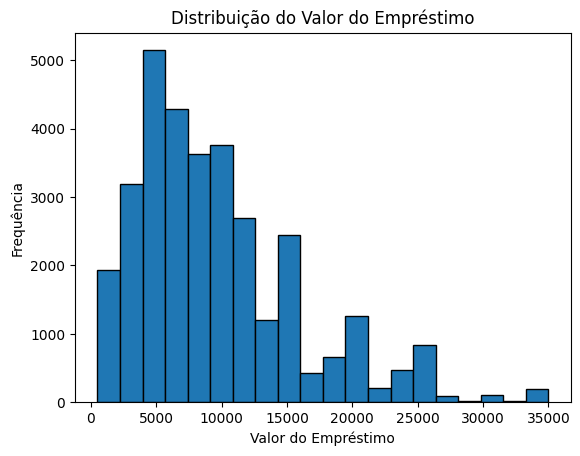

In [ ]:
# Criar um histograma para visualizar a distribuição do valor do empréstimo (loan_amnt) e entender melhor como os valores estão distribuídos.
plt.hist(df['loan_amnt'], bins=20, edgecolor='black')
plt.title('Distribuição do Valor do Empréstimo')
plt.xlabel('Valor do Empréstimo')
plt.ylabel('Frequência')
plt.show()

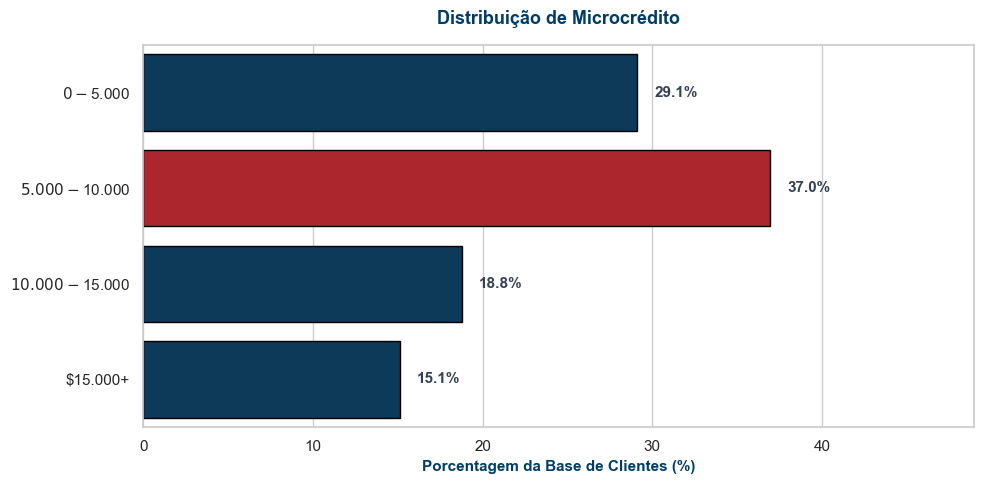

In [ ]:
# Criar um gráfico de barras para visualizar a distribuição dos empréstimos por faixa de valor, destacando os picos de frequência e facilitando a compreensão dos dados para o Storytelling.

# Definir as faixas comerciais personalizadas conforme a proposta do Storytelling
bins = [0, 5000, 10000, 15000, df['loan_amnt'].max()]
labels = ['$0 - $5.000', '$5.000 - $10.000', '$10.000 - $15.000', '$15.000+']

# Agrupa os valores dos empréstimos (loan_amnt) dentro das faixas criadas (Categorização)
df['faixa_emprestimo'] = pd.cut(df['loan_amnt'], bins=bins, labels=labels, include_lowest=True)

# Calcula a porcentagem matemática exata que cada faixa representa na base total
porcentagem = (df['faixa_emprestimo'].value_counts(normalize=True).sort_index() * 100)

# Configurar o tema de fundo do Seaborn para aplicar uma grade elegante
sns.set_theme(style="whitegrid")

# Definir as cores oficiais (Azul Mackenzie por padrão, Vermelho para o pico de frequência)
cores_palette = ['#003D66'] * len(labels)
pico_index = porcentagem.values.argmax()
cores_palette[pico_index] = '#C11119'

# Plotar o gráfico horizontal utilizando os dados calculados na célula anterior
plt.figure(figsize=(10, 5))
# Ajuste: adicionamos 'hue=labels' e 'legend=False' para atender às novas diretrizes do Seaborn
ax = sns.barplot(x=porcentagem.values, y=labels, hue=labels, palette=cores_palette, legend=False, edgecolor='black')

# Adicionar os números das porcentagens exatas na ponta de cada barra
for bar in ax.patches:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
             va='center', ha='left', fontsize=11, fontweight='bold', color='#334155')

# Configurações de títulos e eixos estruturados
plt.title('Distribuição de Microcrédito', fontsize=13, fontweight='bold', color='#003D66', pad=15)
plt.xlabel('Porcentagem da Base de Clientes (%)', fontsize=11, fontweight='bold', color='#003D66')
plt.xlim(0, porcentagem.max() + 12)
plt.tight_layout()
plt.show()

In [ ]:
#    ANÁLISE DE CORRELAÇÃO: Situação atual (Loan status) vs. Problema financeiros anteriores (cb_person_default_on_file) 
#  O coeficiente varia de -1 a 1 e indica a força da relação linear entre Situação atual e Problema financeiros anteriores:

# 1. Próximo de -1 (Correlação Negativa Forte):
#  Indica que possivelmente quanto mais problemas financeiros anteriores (cb_person_default_on_file = 'Y'),
# menor a probabilidade de um status de inadimplência atual.

# 2. Próximo de 0 (Correlação Linear Fraca ou Ausente):
#  Indica que possivelmentenão há uma relação linear relevante entre as variáveis.
# Nesse caso, os problemas financeiros anteriores não influenciam significativamente o status do empréstimo.

# 3. Próximo de 1 (Correlação Positiva Forte):
#  Indica que possivelmente quanto mais problemas financeiros anteriores (cb_person_default_on_file = 'Y'),
# maior a probabilidade de um status de inadimplência atual.

df['cb_person_default_on_file_num'] = df['cb_person_default_on_file'].map({'Y':1,'N':0})
correlação_situação_vs_problemas = df['loan_status'].corr(df['cb_person_default_on_file_num'])
print(f"O Coeficiente de Correlação é: {correlação_situação_vs_problemas:.4f}")

O Coeficiente de Correlação é: 0.1791


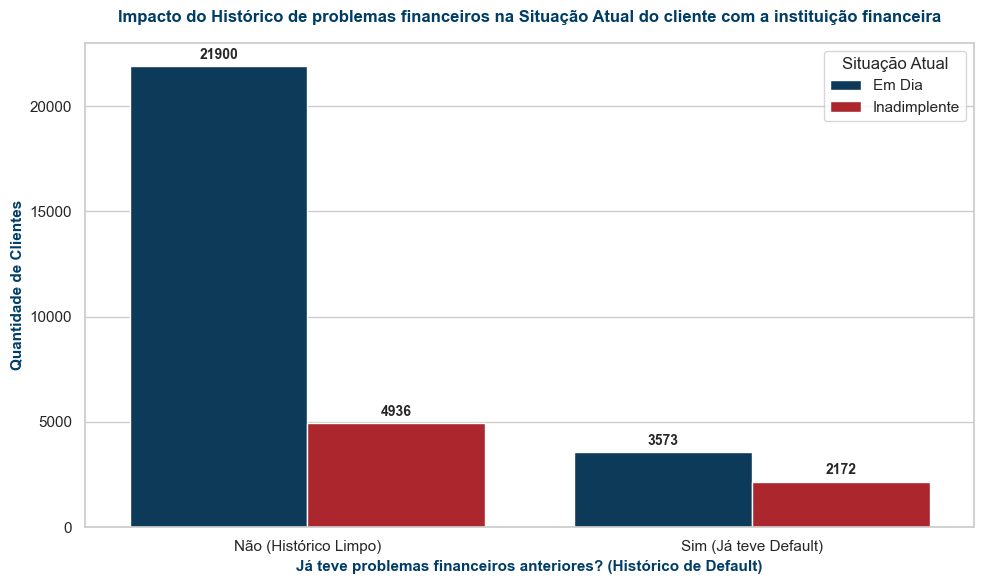

In [ ]:
# Criar uma visualização para mostrar a relação entre o histórico de inadimplência e a situação atual do cliente com a instituição financeira.
# Configura o estilo do fundo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Adicionado o parâmetro 'order' para garantir que 'N' seja o primeiro (0) e 'Y' o segundo (1)
ax = sns.countplot(
    x='cb_person_default_on_file', 
    hue='loan_status', 
    data=df, 
    order=['N', 'Y'], # ordem explícita para garantir que 'N' (0) apareça antes de 'Y' (1)
    palette=['#003D66', '#C11119'] # Azul e Vermelho
)

# Configurações de títulos e legendas limpas para o Storytelling
plt.title('Impacto do Histórico de problemas financeiros na Situação Atual do cliente com a instituição financeira', fontsize=12, fontweight='bold', color='#003D66', pad=15)
plt.xlabel('Já teve problemas financeiros anteriores? (Histórico de Default)', fontsize=11, fontweight='bold', color='#003D66')
plt.ylabel('Quantidade de Clientes', fontsize=11, fontweight='bold', color='#003D66')

# Agora ajustando para o 0, 1 bater exatamente com a ordem ['N', 'Y'] definida acima
plt.xticks(ticks=[0, 1], labels=['Não (Histórico Limpo)', 'Sim (Já teve Default)'])
plt.legend(title='Situação Atual', labels=['Em Dia', 'Inadimplente'])

# Adicionar os números exatos em cima de cada barra para dar precisão analítica
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# --- ANÁLISE DE CORRELAÇÃO: RENDA PESSOAL vs. TAXA DE JUROS ---
#  O coeficiente varia de -1 a 1 e indica a força da relação linear entre Renda e Juros:

# 1. Próximo de -1 (Correlação Negativa Forte):
#  Indica que possivelmente quanto maior a renda, menores tendem a ser os juros.

# 2. Próximo de 0 (Correlação Linear Fraca ou Ausente):
#  Indica que possivelmente não há uma relação linear relevante entre as variáveis.
# Nesse caso, a renda isoladamente não influencia significativamente a taxa de juros

# 3. Próximo de 1 (Correlação Positiva Forte):
#  Indica que possivelmente quanto maior a renda, maiores tendem a ser os juros.

correlacao_renda_pessoal = df['person_income'].corr(df['loan_int_rate'])

print(f"O Coeficiente de Correlação é: {correlacao_renda_pessoal:.4f}")

O Coeficiente de Correlação de Pearson é: 0.0008


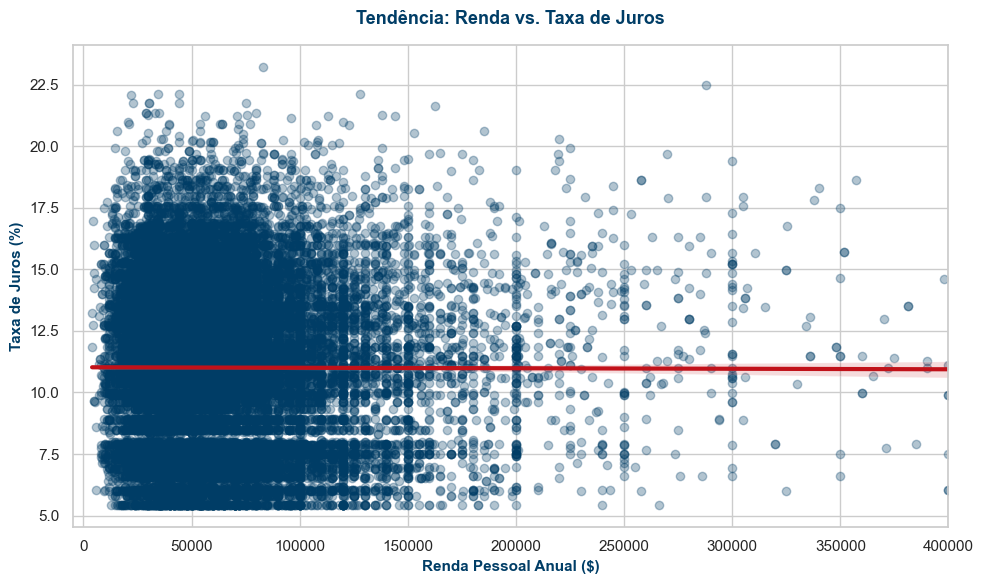

In [ ]:
# Gráfico de Tendência: Renda vs. Juros

# Configurar o tema de fundo do Seaborn para um visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Filtramos temporariamente a exibição para rendas até $400.000 para remover o efeito de distorção da análise do outlier de $6M
df_visual = df[df['person_income'] <= 400000]

# Criar o gráfico de dispersão com linha de tendência (regressão linear) para mostrar a relação entre renda pessoal e taxa de juros
sns.regplot(
    data=df_visual, 
    x='person_income', 
    y='loan_int_rate', 
    scatter_kws={'alpha': 0.3, 'color': '#003D66'}, # Pontos em Azul Marinho com transparência
    line_kws={'color': '#C11119', 'linewidth': 3}   # Linha de tendência em Vermelho destacado
)

# Configurações de títulos e eixos estruturados para o Storytelling
plt.title('Tendência: Renda vs. Taxa de Juros', fontsize=13, fontweight='bold', color='#003D66', pad=15)
plt.xlabel('Renda Pessoal Anual ($)', fontsize=11, fontweight='bold', color='#003D66')
plt.ylabel('Taxa de Juros (%)', fontsize=11, fontweight='bold', color='#003D66')

# Ajustar os limites para o gráfico ficar perfeitamente enquadrado
plt.xlim(-5000, 400000)
plt.tight_layout()
plt.show()

In [ ]:
# --- ANÁLISE DE CORRELAÇÃO: HISTÓRICO DE CRÉDITO vs. TAXA DE JUROS ---
# O Coeficiente de Pearson avalia a relação linear entre o histórico de crédito e a taxa de juros:

# 1. Próximo de -1:
# Indica que possivelmente quanto maior o histórico, menor tende a ser a taxa de juros.

# 2. Próximo de 0:
# Indica ausência de relação linear relevante entre as variáveis.
# Nesse caso, o histórico de crédito isoladamente não parece influenciar bem a taxa de juros.

# 3. Próximo de 1:
# Indica que possivelmente quanto maior o histórico, maior tende a ser a taxa de juros.

correlacao_tempo_credito = df['cb_person_cred_hist_length'].corr(df['loan_int_rate'])

print(f"O Coeficiente de Correlação é: {correlacao_tempo_credito:.4f}")

O Coeficiente de Correlação é: 0.0167


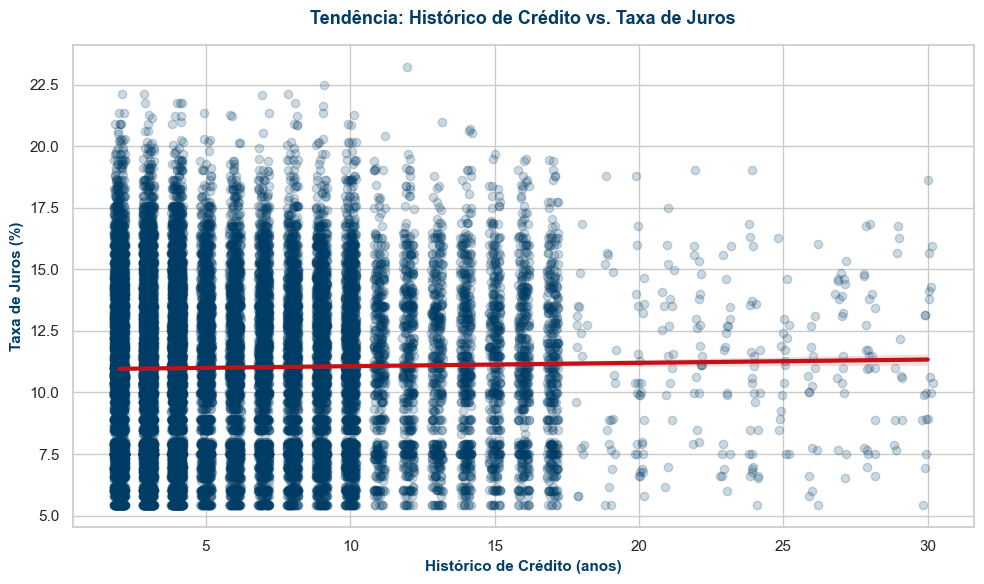

In [ ]:
# Gráfico de Tendência: Histórico de Crédito vs. Juros

# Configurar o tema de fundo do Seaborn para manter a padronização limpa
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Adicionamos 'x_jitter=0.2' para suavizar as colunas rígidas de pontos e melhorar a percepção de densidade
sns.regplot(
    data=df, 
    x='cb_person_cred_hist_length', 
    y='loan_int_rate', 
    x_jitter=0.2,                                   # Afasta levemente os pontos para os lados, removendo o visual em barras
    scatter_kws={'alpha': 0.2, 'color': '#003D66'}, # Pontos em Azul Marinho com transparência suave
    line_kws={'color': '#C11119', 'linewidth': 3}   # Linha de tendência em Vermelho destacado
)

# Configurações de títulos e eixos estruturados para o Storytelling
plt.title('Tendência: Histórico de Crédito vs. Taxa de Juros', fontsize=13, fontweight='bold', color='#003D66', pad=15)
plt.xlabel('Histórico de Crédito (anos)', fontsize=11, fontweight='bold', color='#003D66')
plt.ylabel('Taxa de Juros (%)', fontsize=11, fontweight='bold', color='#003D66')

# Ajustar as margens para o enquadramento perfeito no slide
plt.tight_layout()
plt.show()